In [ ]:
import os
import pandas as pd

# Set your dataset base directory here
base_path = '/content/drive/MyDrive/Tomato_Dataset'

# Class names from your data.yaml
class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']
num_classes = len(class_names)

# Helper to process one split (train/valid/test)
def process_split(split):
    image_dir = os.path.join(base_path, split, 'images')
    label_dir = os.path.join(base_path, split, 'labels')
    data = []

    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            label_path = os.path.join(label_dir, filename)
            image_filename = filename.replace('.txt', '.jpg')  # assuming .jpg images
            image_path = os.path.join(image_dir, image_filename)

            # Initialize a zero label vector
            label_vector = [0] * num_classes

            # Read YOLO annotations
            with open(label_path, 'r') as f:
                for line in f:
                    class_id = int(line.strip().split()[0])
                    label_vector[class_id] = 1  # multi-label

            data.append([image_path] + label_vector)

    return pd.DataFrame(data, columns=['image_path'] + class_names)

# Process all splits
df_train = process_split('train')
df_valid = process_split('valid')
df_test = process_split('test')

#  Merge all into one CSV (or keep separate)
df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)

# Save to CSV
output_csv_path = os.path.join(base_path, 'tomato_multilabel_dataset.csv')
df_all.to_csv(output_csv_path, index=False)

print(f"CSV saved to: {output_csv_path}")

CSV saved to: /content/drive/MyDrive/Tomato_Dataset/tomato_multilabel_dataset.csv


In [ ]:
import os
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

# Step 1: Clear GPU memory
import gc
torch.cuda.empty_cache()
gc.collect()

# Step 2: Read the cleaned CSV
csv_path = os.path.join(base_path, 'tomato_multilabel_dataset.csv')
df = pd.read_csv(csv_path)

# Step 3: Remove broken image paths
df = df[df['image_path'].apply(lambda x: Path(x).exists())].reset_index(drop=True)

# Step 4: Split the dataset
df_train = df[df['image_path'].str.contains('/train/')]
df_valid = df[df['image_path'].str.contains('/valid/')]
df_test  = df[df['image_path'].str.contains('/test/')]

# Step 5: Define image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Step 6: Define custom dataset class
class MultiLabelTomatoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.labels = dataframe.iloc[:, 1:].values.astype('float32')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx, 0]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx])
        return image, label

# Step 7: DataLoaders (Batch size = 32)
train_loader = DataLoader(MultiLabelTomatoDataset(df_train, transform=transform), batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(MultiLabelTomatoDataset(df_valid, transform=transform), batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(MultiLabelTomatoDataset(df_test,  transform=transform), batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(df_train)} | Valid: {len(df_valid)} | Test: {len(df_test)} — all paths verified ")

Train: 645 | Valid: 61 | Test: 31 — all paths verified 


In [ ]:
import torch
import torch.nn as nn
from torchvision import models  # For ResNet
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import os

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pre-trained ResNet50 and modify final layer
resnet_model = models.resnet50(pretrained=True)
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, 7)  # 7 disease classes (multi-label)
resnet_model = resnet_model.to(device)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)

print("Model ready with ResNet50 + 7 output neurons (multi-label)")

# Create folder to save best model
os.makedirs("saved_models", exist_ok=True)

# Evaluation function
def evaluate(model, dataloader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()

            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return acc, prec, rec, f1

# Training loop
def train(model, train_loader, valid_loader, criterion, optimizer, num_epochs=10):
    best_f1 = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        acc, prec, rec, f1 = evaluate(model, valid_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] — Loss: {running_loss:.4f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), "saved_models/best_resnet50_multilabel.pth")
            print(" Best model saved!")

# Start training
train(resnet_model, train_loader, valid_loader, criterion, optimizer, num_epochs=15)


Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready with ResNet50 + 7 output neurons (multi-label)
Epoch [1/15] — Loss: 8.3770 | Acc: 0.7377 | Prec: 0.9005 | Recall: 0.7327 | F1: 0.7818
 Best model saved!
Epoch [2/15] — Loss: 2.1701 | Acc: 0.8197 | Prec: 0.9452 | Recall: 0.7671 | F1: 0.8275
 Best model saved!
Epoch [3/15] — Loss: 1.0440 | Acc: 0.8689 | Prec: 0.9294 | Recall: 0.8448 | F1: 0.8621
 Best model saved!
Epoch [4/15] — Loss: 0.7384 | Acc: 0.8525 | Prec: 0.9217 | Recall: 0.7981 | F1: 0.8324
Epoch [5/15] — Loss: 0.6395 | Acc: 0.8361 | Prec: 0.9275 | Recall: 0.7981 | F1: 0.8346
Epoch [6/15] — Loss: 0.5970 | Acc: 0.8525 | Prec: 0.9217 | Recall: 0.7624 | F1: 0.8052
Epoch [7/15] — Loss: 0.7461 | Acc: 0.8361 | Prec: 0.8571 | Recall: 0.7981 | F1: 0.8212
Epoch [8/15] — Loss: 0.5184 | Acc: 0.8525 | Prec: 0.9217 | Recall: 0.7981 | F1: 0.8324
Epoch [9/15] — Loss: 0.4610 | Acc: 0.8361 | Prec: 0.9208 | Recall: 0.7867 | F1: 0.8260
Epoch [10/15] — Loss: 0.3295 | Acc: 0.8361 | Prec: 0.9281 | Recall: 0.7913 | F1: 0.8315
Epoch [11/15]

In [ ]:
from sklearn.metrics import classification_report

# Load best saved ResNet50 model
resnet_model.load_state_dict(torch.load("saved_models/best_resnet50_multilabel.pth"))
resnet_model.eval()

# Evaluate on test set
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification Report (per class)
target_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']
print("Classification Report on Test Set:\n")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

Classification Report on Test Set:

                precision    recall  f1-score   support

Bacterial Spot       1.00      0.50      0.67         2
  Early_Blight       1.00      1.00      1.00        15
       Healthy       1.00      1.00      1.00         7
   Late_blight       1.00      1.00      1.00         9
     Leaf Mold       0.75      0.75      0.75         4
   Target_Spot       1.00      1.00      1.00         2
    black spot       1.00      0.89      0.94         9

     micro avg       0.98      0.94      0.96        48
     macro avg       0.96      0.88      0.91        48
  weighted avg       0.98      0.94      0.95        48
   samples avg       0.99      0.95      0.96        48



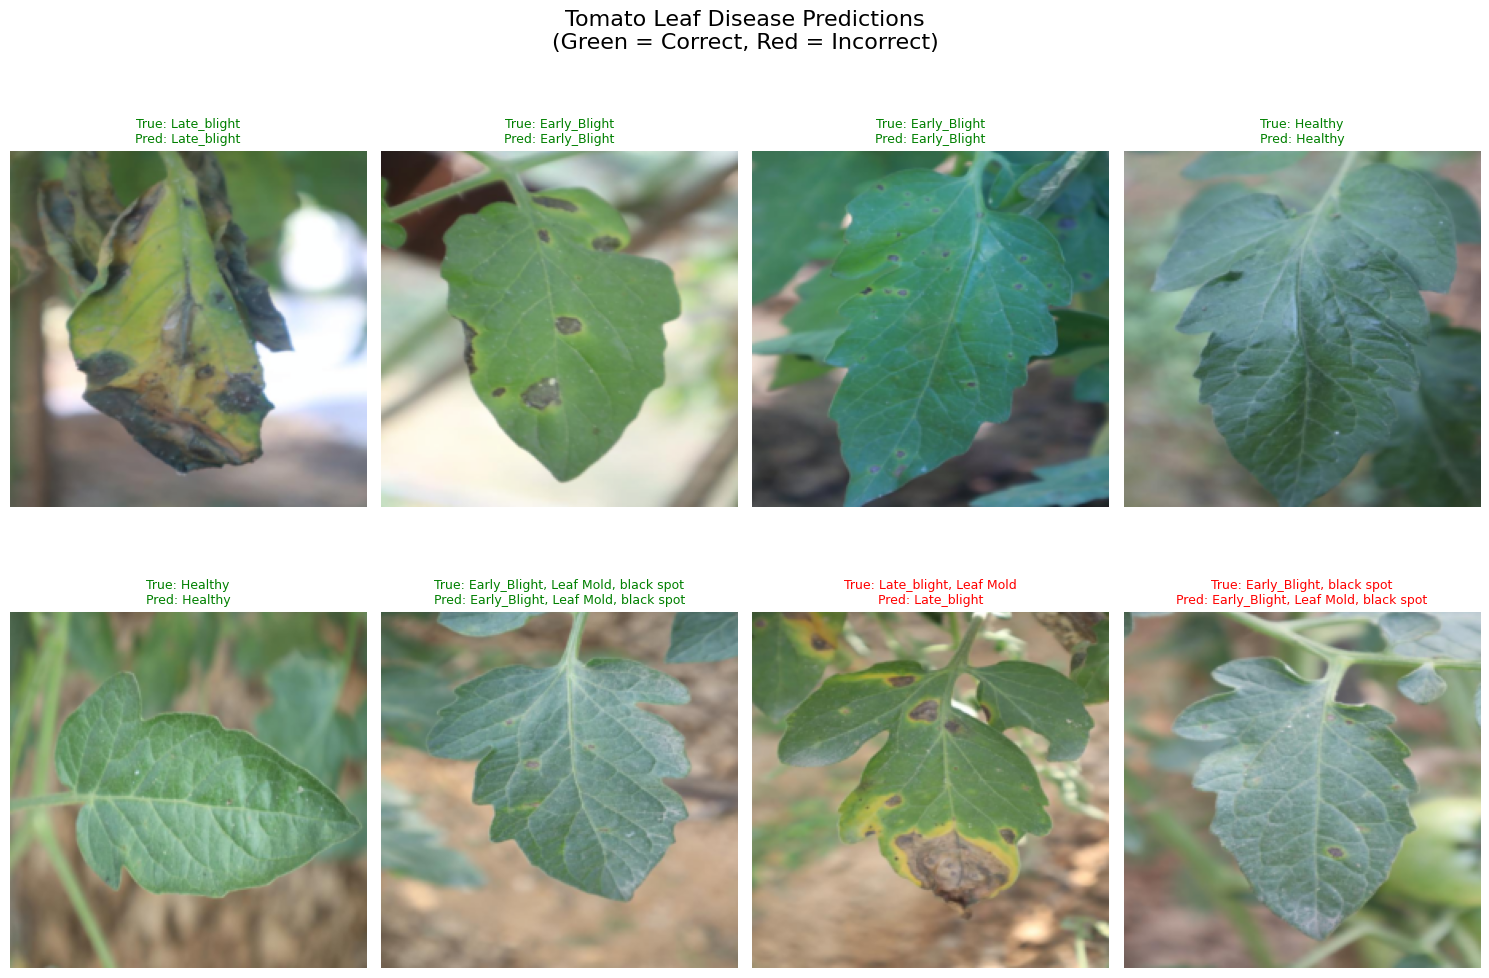

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Disease class names
class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']

# Number of samples to show
samples_to_show = 8
resnet_model.eval()

images_shown = 0

plt.figure(figsize=(15, 10))

with torch.no_grad():
    for images, labels in test_loader:
        outputs = resnet_model(images.to(device))
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float().cpu()

        for i in range(images.size(0)):
            if images_shown >= samples_to_show:
                break

            # Unnormalize the image (assuming standard ImageNet normalization)
            image = images[i].permute(1, 2, 0).numpy()
            image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            image = np.clip(image, 0, 1)

            # Get label names
            true_labels = [class_names[j] for j in range(len(class_names)) if labels[i][j] == 1]
            pred_labels = [class_names[j] for j in range(len(class_names)) if preds[i][j] == 1]

            # Plot
            plt.subplot(2, 4, images_shown + 1)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"True: {', '.join(true_labels)}\nPred: {', '.join(pred_labels)}",
                      fontsize=9, color='green' if true_labels == pred_labels else 'red')

            images_shown += 1

        if images_shown >= samples_to_show:
            break

plt.tight_layout()
plt.suptitle("Tomato Leaf Disease Predictions\n(Green = Correct, Red = Incorrect)", fontsize=16, y=1.05)
plt.show()


In [ ]:
def evaluate_fitness_fsro(params, train_loader, valid_loader):
    lr, dropout, weight_decay = params

    # Load pre-trained ResNet50 and modify for multi-label
    import torchvision.models as models
    model = models.resnet50(pretrained=True)

    # Modify the final layer for multi-label output (7 classes)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_ftrs, 7)
    )
    model = model.to(device)

    # Optimizer and multi-label loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    # Quick training on few batches
    model.train()
    train_iter = iter(train_loader)
    for _ in range(2):  # Use 2 mini-batches for speed
        try:
            images, labels = next(train_iter)
        except StopIteration:
            break
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluation on few batches
    model.eval()
    y_true, y_pred = [], []
    valid_iter = iter(valid_loader)
    with torch.no_grad():
        for _ in range(2):
            try:
                images, labels = next(valid_iter)
            except StopIteration:
                break
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    from sklearn.metrics import f1_score
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return f1  # FSRO aims to maximize F1 score


In [ ]:
import numpy as np
import random

# Define hyperparameter bounds
param_bounds = {
    'learning_rate': (1e-5, 1e-2),
    'dropout_rate': (0.1, 0.5),
    'weight_decay': (0.0, 1e-2)
}

# Define FSRO agent
class Frog:
    def __init__(self):
        self.position = {
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'dropout_rate': random.uniform(*param_bounds['dropout_rate']),
            'weight_decay': random.uniform(*param_bounds['weight_decay'])
        }
        self.score = 0.0


In [ ]:
def fsro_optimize_resnet(train_loader, valid_loader, n_frogs=6, n_iterations=10):
    frogs = [Frog() for _ in range(n_frogs)]

    # Evaluate initial scores
    for frog in frogs:
        frog.score = evaluate_fitness_fsro(
            [frog.position['learning_rate'],
             frog.position['dropout_rate'],
             frog.position['weight_decay']],
            train_loader, valid_loader
        )

    # Begin FSRO evolution
    for iteration in range(n_iterations):
        frogs.sort(key=lambda f: f.score, reverse=True)  # higher is better
        best = frogs[0]
        worst = frogs[-1]

        # Move the worst frog toward the best frog
        for key in worst.position:
            step = random.random() * (best.position[key] - worst.position[key])
            new_val = worst.position[key] + step

            # Clamp to bounds
            lb, ub = param_bounds[key]
            worst.position[key] = max(min(new_val, ub), lb)

        # Re-evaluate the worst frog
        worst.score = evaluate_fitness_fsro(
            [worst.position['learning_rate'],
             worst.position['dropout_rate'],
             worst.position['weight_decay']],
            train_loader, valid_loader
        )

        print(f"FSRO Iteration {iteration+1}/{n_iterations} | Best F1: {best.score:.4f}")

    best_frog = max(frogs, key=lambda f: f.score)
    return best_frog.position, best_frog.score


In [ ]:
best_fsro_resnet_params, best_fsro_resnet_f1 = fsro_optimize_resnet(train_loader, valid_loader)
print("Best FSRO Parameters (ResNet50):", best_fsro_resnet_params)
print("Best FSRO Validation F1:", best_fsro_resnet_f1)



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are depreca

FSRO Iteration 1/10 | Best F1: 0.3133


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FSRO Iteration 2/10 | Best F1: 0.3133


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...

FSRO Iteration 8/10 | Best F1: 0.3133


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FSRO Iteration 9/10 | Best F1: 0.3133


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FSRO Iteration 10/10 | Best F1: 0.3133
Best FSRO Parameters (ResNet50): {'learning_rate': 0.0008411087520623282, 'dropout_rate': 0.10654789203198485, 'weight_decay': 0.009779420155251307}
Best FSRO Validation F1: 0.3133478612167839


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim # Import torch.optim

def evaluate_model_fsro(params, train_loader, val_loader, device):
    lr = params['learning_rate']
    dropout = params['dropout_rate']
    weight_decay = params['weight_decay']

    model = models.resnet50(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_ftrs, 7)  # 7 multi-label classes
    )
    model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()
    for epoch in range(1):  # One-epoch fast training
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    return avg_val_loss

In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim # Import torch.optim
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torchvision.models as models # Import models for evaluate_model_fsro

# Define hyperparameter bounds
param_bounds = {
    'learning_rate': (1e-5, 1e-2),
    'dropout_rate': (0.1, 0.5),
    'weight_decay': (0.0, 1e-2)
}

# Define FSRO agent
class Frog:
    def __init__(self):
        self.position = {
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'dropout_rate': random.uniform(*param_bounds['dropout_rate']),
            'weight_decay': random.uniform(*param_bounds['weight_decay'])
        }
        self.score = 0.0

def fsro_optimize_with_logging(train_loader, valid_loader, n_frogs=6, n_iterations=10):
    frogs = [Frog() for _ in range(n_frogs)]

    # Initial evaluation
    for frog in frogs:
        frog.score = evaluate_model_fsro(frog.position, train_loader, valid_loader, device)
        print(f"Initial score: {frog.score:.4f} | Position: {frog.position}")

    for iteration in range(n_iterations):
        frogs.sort(key=lambda f: f.score)  # minimize validation loss
        best = frogs[0]
        worst = frogs[-1]

        print(f"\nFSRO Iteration {iteration+1}/{n_iterations}")
        print(f" Best score so far: {best.score:.4f}")
        print(f" Worst score: {worst.score:.4f}")

        # Move worst toward best
        for key in worst.position:
            step = random.random() * (best.position[key] - worst.position[key])
            worst.position[key] += step

            # Clamp within bounds
            low, high = param_bounds[key]
            worst.position[key] = max(min(worst.position[key], high), low)

        # Re-evaluate updated worst frog
        worst.score = evaluate_model_fsro(worst.position, train_loader, valid_loader, device)
        print(f" Updated worst frog score: {worst.score:.4f} | New position: {worst.position}")

    frogs.sort(key=lambda f: f.score)
    best_frog = frogs[0]
    return best_frog.position, best_frog.score

In [ ]:
best_fsro_params, best_fsro_loss = fsro_optimize_with_logging(train_loader, valid_loader)
print("\nFinal FSRO-Optimized Hyperparameters:")
print(best_fsro_params)
print(f"Validation Loss: {best_fsro_loss:.4f}")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Initial score: 41.4537 | Position: {'learning_rate': 0.00945302695591389, 'dropout_rate': 0.23682350604653843, 'weight_decay': 0.001231175894437988}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Initial score: 6.9546 | Position: {'learning_rate': 0.0031795180364583677, 'dropout_rate': 0.25041107006901464, 'weight_decay': 0.0017853987991283803}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...

 Updated worst frog score: 1.5764 | New position: {'learning_rate': 0.004973419993444434, 'dropout_rate': 0.2983723056362834, 'weight_decay': 0.007573405791663046}

FSRO Iteration 9/10
 Best score so far: 0.4558
 Worst score: 1.5764


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Updated worst frog score: 0.4607 | New position: {'learning_rate': 0.004795311346857143, 'dropout_rate': 0.2682244119815614, 'weight_decay': 0.0078045361410263945}

FSRO Iteration 10/10
 Best score so far: 0.4558
 Worst score: 0.4716


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


 Updated worst frog score: 0.4668 | New position: {'learning_rate': 0.00445556452775527, 'dropout_rate': 0.1717638072052265, 'weight_decay': 0.007311624677266819}

Final FSRO-Optimized Hyperparameters:
{'learning_rate': 0.004306918060637267, 'dropout_rate': 0.18782309264396438, 'weight_decay': 0.008284571157799034}
Validation Loss: 0.4558


In [ ]:
import torchvision.models as models

# Use the best parameters obtained from FSRO
best_params = best_fsro_params  # or assign manually if needed
# best_params = {'learning_rate': 0.0043, 'dropout_rate': 0.4072, 'weight_decay': 0.0031}

# Initialize ResNet50 model
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(best_params['dropout_rate']),
    nn.Linear(num_ftrs, 7)
)
model.to(device)

# Define loss and optimizer
criterion = nn.BCEWithLogitsLoss()  # Multi-label loss
optimizer = torch.optim.Adam(model.parameters(),
                             lr=best_params['learning_rate'],
                             weight_decay=best_params['weight_decay'])

# Final training loop
n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{n_epochs}], Training Loss: {avg_loss:.4f}")

# Save the trained model
torch.save(model.state_dict(), "best_fsro_resnet_model.pth")
print("✅ Final ResNet model trained with FSRO and saved.")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/20], Training Loss: 0.5098
Epoch [2/20], Training Loss: 0.4259
Epoch [3/20], Training Loss: 0.4303
Epoch [4/20], Training Loss: 0.4170
Epoch [5/20], Training Loss: 0.4055
Epoch [6/20], Training Loss: 0.4056
Epoch [7/20], Training Loss: 0.3923
Epoch [8/20], Training Loss: 0.3936
Epoch [9/20], Training Loss: 0.3881
Epoch [10/20], Training Loss: 0.3863
Epoch [11/20], Training Loss: 0.4037
Epoch [12/20], Training Loss: 0.3857
Epoch [13/20], Training Loss: 0.3895
Epoch [14/20], Training Loss: 0.3899
Epoch [15/20], Training Loss: 0.3895
Epoch [16/20], Training Loss: 0.3961
Epoch [17/20], Training Loss: 0.4057
Epoch [18/20], Training Loss: 0.3908
Epoch [19/20], Training Loss: 0.3997
Epoch [20/20], Training Loss: 0.4014
✅ Final ResNet model trained with FSRO and saved.


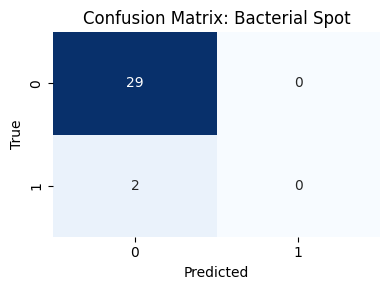

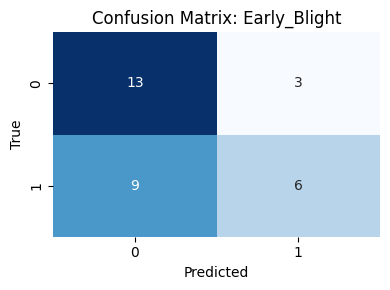

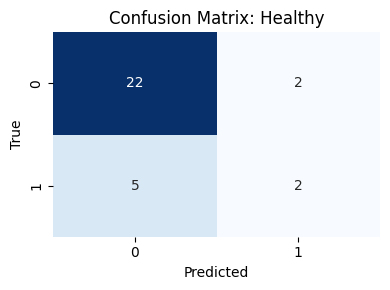

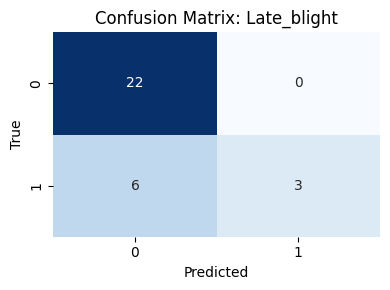

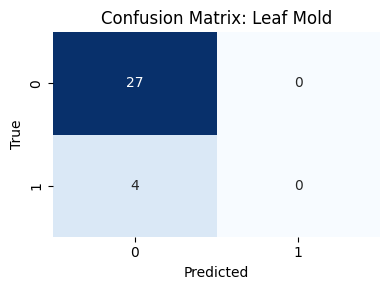

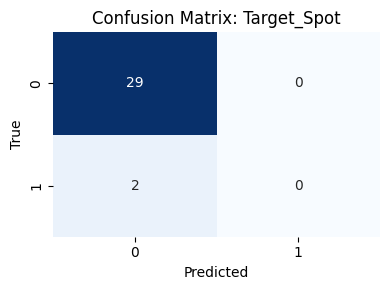

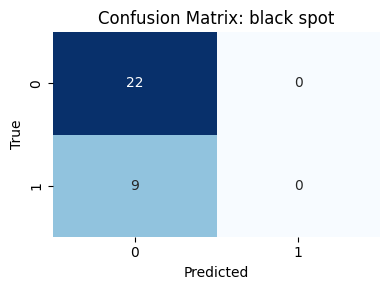

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch # Import torch

# Ensure the model is in evaluation mode
model.eval()

# Initialize lists to store true labels and scores
y_true, y_scores = [], []

# Iterate over the test data loader
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs) # Apply sigmoid for multi-label probabilities

        y_true.append(labels.cpu().numpy())
        y_scores.append(probs.cpu().numpy())

# Concatenate the lists into numpy arrays
y_true = np.vstack(y_true)
y_scores = np.vstack(y_scores)

# Threshold predictions
y_pred = (y_scores > 0.5).astype(int)

# Plot 7 confusion matrices
class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot'] # Define class_names

for i in range(len(class_names)): # Iterate through each class
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix: {class_names[i]}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

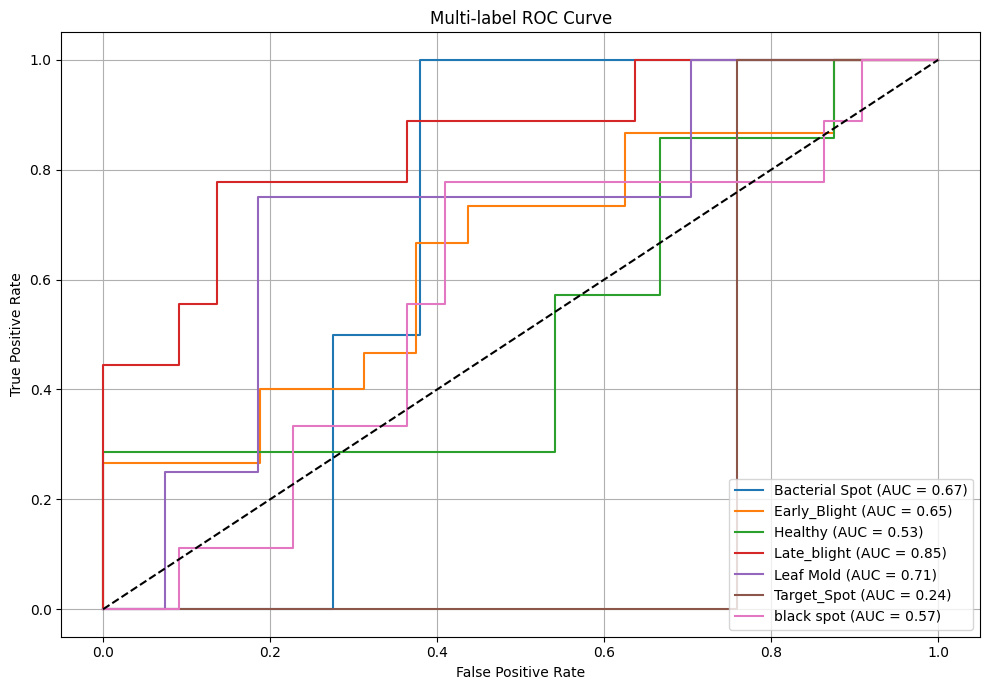

In [ ]:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

model.eval()
y_true, y_scores = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)

        y_true.append(labels.cpu().numpy())
        y_scores.append(probs.cpu().numpy())

y_true = np.vstack(y_true)
y_scores = np.vstack(y_scores)

# Plot ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']

plt.figure(figsize=(10, 7))
for i in range(7):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-label ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
files.download("best_fsro_resnet_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>